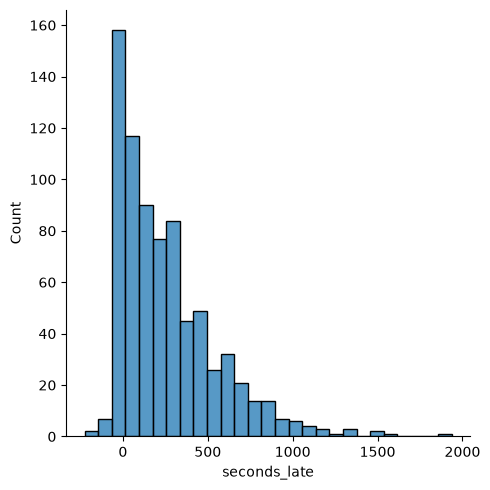

In [1]:
import seaborn
from pandas import DataFrame
import csv
from datetime import datetime

deltas = []
with open("out.txt", "r") as file:
    csvreader = csv.reader(file)

    for r in csvreader:
        expected = datetime.fromisoformat(r[2])
        actual = datetime.fromisoformat(r[3])

        if expected > datetime.now():
            continue
        # if excpected < actual -> bus came late
        delta =  (actual - expected).seconds  if expected < actual else (expected - actual).seconds * -1
        deltas.append(delta)


points = {"seconds_late" : list(filter(lambda s : abs(s) < 2000,deltas))}

df = DataFrame(data=points)
seaborn.displot(df, x="seconds_late")
